<a href="https://colab.research.google.com/github/Pavanaj06/HER-Predictor/blob/main/HER%20FIN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install xgboost

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder

from sklearn.impute import SimpleImputer

from sklearn.metrics import r2_score,mean_absolute_error

from xgboost import XGBRegressor

import joblib

In [ ]:
from google.colab import files

uploaded=files.upload()

Saving 135 HER_Dataset_Batch1_Batch2_with_engineered_features.xlsx to 135 HER_Dataset_Batch1_Batch2_with_engineered_features.xlsx


In [ ]:
df=pd.read_excel(next(iter(uploaded)))

df.head()
df=df.drop(columns=["Unnamed: 0","ID","Reference"],errors="ignore")

In [ ]:
# Remove completely empty columns
df = df.dropna(axis=1, how='all')

# Remove unwanted columns if present
df = df.drop(columns=["Unnamed: 0","Unnamed: 1","ID","Reference"], errors="ignore")

from sklearn.impute import SimpleImputer

num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include="object").columns

# Fill missing values
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
print(df.columns.tolist())

['Steel', 'Type', 'Thickness_mm', 'YS_MPa', 'UTS_MPa', 'n_value', 'Clearance_pct', 'Hole_Preparation', 'Burr_Orientation', 'Punch_Geometry', 'HER_pct', 'Strength_Ratio_YS_UTS', 'UTS_x_n']


In [ ]:
print(df.columns.tolist())

['Steel', 'Type', 'Thickness_mm', 'YS_MPa', 'UTS_MPa', 'n_value', 'Clearance_pct', 'Hole_Preparation', 'Burr_Orientation', 'Punch_Geometry', 'HER_pct', 'Strength_Ratio_YS_UTS', 'UTS_x_n']


In [ ]:
# Input and Output

X = df.drop("HER_pct", axis=1)
y = df["HER_pct"]

In [ ]:
# Identify numerical and categorical columns

cat_features = X.select_dtypes(include="object").columns.tolist()
num_features = X.select_dtypes(exclude="object").columns.tolist()

print("Categorical:", cat_features)
print("Numerical:", num_features)

Categorical: ['Steel', 'Type', 'Hole_Preparation', 'Burr_Orientation', 'Punch_Geometry']
Numerical: ['Thickness_mm', 'YS_MPa', 'UTS_MPa', 'n_value', 'Clearance_pct', 'Strength_Ratio_YS_UTS', 'UTS_x_n']


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [ ]:
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ))
])

NameError: name 'preprocessor' is not defined

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

cat_features = X.select_dtypes(include="object").columns.tolist()
num_features = X.select_dtypes(exclude="object").columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
        ("num", "passthrough", num_features)
    ]
)

print("Preprocessor Created Successfully")

Preprocessor Created Successfully


In [ ]:
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ))
])

In [ ]:
model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

pred = model.predict(X_test)

print("R² Score :", round(r2_score(y_test, pred),4))
print("MAE      :", round(mean_absolute_error(y_test, pred),2))
print("RMSE     :", round(np.sqrt(mean_squared_error(y_test, pred)),2))

R² Score : 0.8311
MAE      : 4.69
RMSE     : 7.47


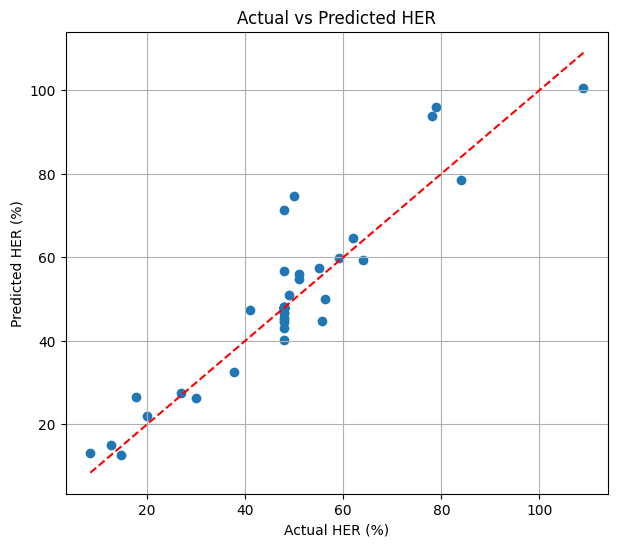

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))
plt.scatter(y_test, pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual HER (%)")
plt.ylabel("Predicted HER (%)")
plt.title("Actual vs Predicted HER")

plt.grid(True)

plt.show()

In [ ]:
feature_names = model.named_steps["preprocessor"].get_feature_names_out()

importance = model.named_steps["regressor"].feature_importances_

importance_df = (
    pd.DataFrame({
        "Feature": feature_names,
        "Importance": importance
    })
    .sort_values(by="Importance", ascending=False)
)

importance_df.head(20)

,Feature,Importance
11,cat__Type_CP,0.183656
12,cat__Type_DP,0.151012
21,cat__Hole_Preparation_Reamed,0.116432
5,cat__Steel_DP1180,0.107286
38,cat__Punch_Geometry_Flat,0.054015
35,cat__Punch_Geometry_Conical,0.052042
42,num__UTS_MPa,0.034126
22,cat__Hole_Preparation_Sheared,0.033085
8,cat__Steel_DP780,0.029347
46,num__UTS_x_n,0.021335


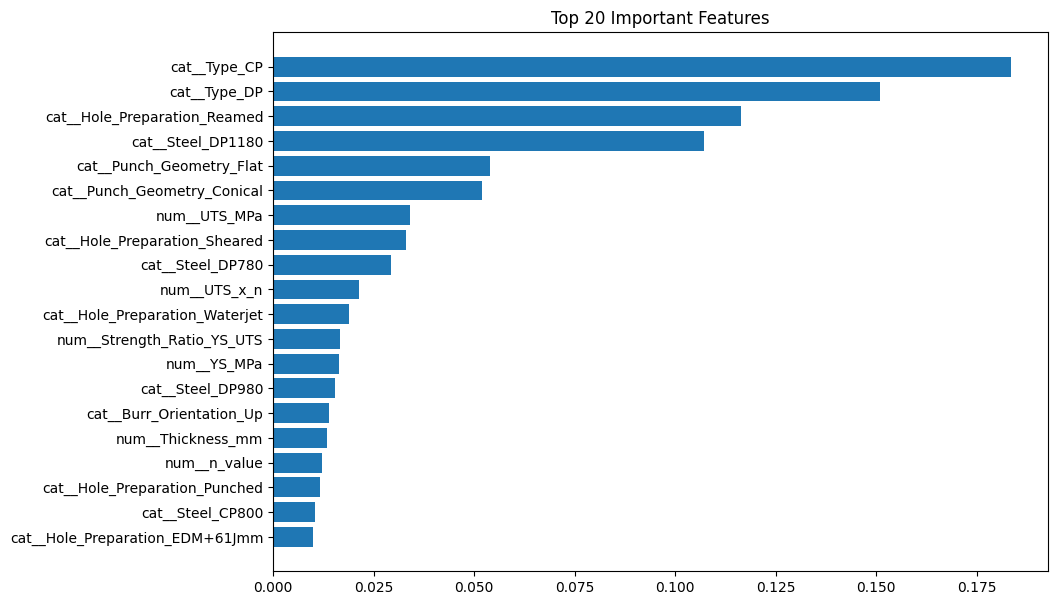

In [ ]:
top20 = importance_df.head(20)

plt.figure(figsize=(10,7))

plt.barh(top20["Feature"], top20["Importance"])

plt.gca().invert_yaxis()

plt.title("Top 20 Important Features")

plt.show()

In [ ]:
import joblib

joblib.dump(model, "HER_XGBoost.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("R² for each fold:", scores)
print("Mean R²:", scores.mean())
print("Std:", scores.std())

R² for each fold: [0.83126953 0.85080526 0.57228982 0.76766839 0.80194469]
Mean R²: 0.7647955393890852
Std: 0.1002628818540143


In [ ]:
XGBRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=5,
    min_child_weight=2,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.9, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=2, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=800,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", XGBRegressor(
        n_estimators=800,
        learning_rate=0.03,
        max_depth=5,
        min_child_weight=2,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42
    ))
])

In [ ]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Steel', 'Type',
                                                   'Hole_Preparation',
                                                   'Burr_Orientation',
                                                   'Punch_Geometry']),
                                                 ('num', 'passthrough',
                                                  ['Thickness_mm', 'YS_MPa',
                                                   'UTS_MPa', 'n_value',
                                                   'Clearance_pct',
                                                   'Strength_Ratio_YS_UTS',
                                                   'UTS_x_n'])])),
                ('regressor',
                 XGBRegressor(base_score=None, boos...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.03,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=5, max_leaves=None, min_child_weight=2,
                              missing=nan, monotone_constraints=None,
                              multi_strategy=None, n_estimators=800,
                              n_jobs=None, num_parallel_tree=None, ...))])

In [ ]:
pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

print("R² :", round(r2_score(y_test, pred),4))
print("MAE :", round(mean_absolute_error(y_test, pred),2))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, pred)),2))

R² : 0.6612
MAE : 5.86
RMSE: 10.58


In [ ]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    "regressor__n_estimators": [300, 500, 700],
    "regressor__learning_rate": [0.03, 0.05, 0.1],
    "regressor__max_depth": [3, 4, 5],
    "regressor__subsample": [0.8, 0.9],
    "regressor__colsample_bytree": [0.8, 0.9]
}
grid = GridSearchCV(
    model,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['Steel',
                                                                          'Type',
                                                                          'Hole_Preparation',
                                                                          'Burr_Orientation',
                                                                          'Punch_Geometry']),
                                                                        ('num',
                                                                         'passthrough',
                                                                         ['Thickness_mm',
                                                                          'YS_MPa',
                                                                          'UTS_MPa',
                                                                          'n_value',
                                                                          'Clearance_pct',
                                                                          'Strength_Ratio_YS_UTS',
                                                                          'UTS_x_n'])])),
                                       ('regressor',
                                        XGBRe...
                                                     min_child_weight=2,
                                                     missing=nan,
                                                     monotone_constraints=None,
                                                     multi_strategy=None,
                                                     n_estimators=800,
                                                     n_jobs=None,
                                                     num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'regressor__colsample_bytree': [0.8, 0.9],
                         'regressor__learning_rate': [0.03, 0.05, 0.1],
                         'regressor__max_depth': [3, 4, 5],
                         'regressor__n_estimators': [300, 500, 700],
                         'regressor__subsample': [0.8, 0.9]},
             scoring='r2')

In [ ]:
best_model = grid.best_estimator_

pred = best_model.predict(X_test)

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

print("R² :", round(r2_score(y_test, pred),4))
print("MAE :", round(mean_absolute_error(y_test, pred),2))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, pred)),2))

R² : 0.7251
MAE : 6.54
RMSE: 9.53


In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    best_model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("Fold Scores:", scores)
print("Mean R²:", scores.mean())
print("Std Dev:", scores.std())

Fold Scores: [0.83263792 0.88145835 0.54454507 0.79458143 0.71990092]
Mean R²: 0.7546247394172817
Std Dev: 0.11756578571724871


In [ ]:
XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
import joblib
joblib.dump(model, "HER_XGBoost.pkl")

['HER_XGBoost.pkl']

In [ ]:
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ))
])

# Train
model.fit(X_train, y_train)

# Predict
pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

print("R² :", round(r2_score(y_test, pred),4))
print("MAE :", round(mean_absolute_error(y_test, pred),2))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, pred)),2))

R² : 0.8311
MAE : 4.69
RMSE: 7.47


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

print("R² :", round(r2_score(y_test, pred),4))
print("MAE :", round(mean_absolute_error(y_test, pred),2))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, pred)),2))

R² : 0.8311
MAE : 4.69
RMSE: 7.47


In [ ]:
df.to_csv("HER_Final_Dataset.csv", index=False)

print("Dataset Saved Successfully!")

Dataset Saved Successfully!


In [ ]:
from google.colab import files

files.download("HER_XGBoost.pkl")
files.download("HER_Final_Dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

files.download("HER_XGBoost.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
def recommend_clearance(
    steel,
    type_,
    thickness,
    ys,
    uts,
    n_value,
    hole_prep,
    burr,
    punch,
    target_her
):

SyntaxError: incomplete input (3833749490.py, line 12)

In [ ]:
def recommend_clearance(
    steel,
    type_,
    thickness,
    ys,
    uts,
    n_value,
    hole_prep,
    burr,
    punch,
    target_her
)

SyntaxError: expected ':' (1438503766.py, line 12)

In [ ]:
def recommend_clearance(
    steel,
    type_,
    thickness,
    ys,
    uts,
    n_value,
    hole_prep,
    burr,
    punch,
    target_her
):
    pass

In [ ]:
import numpy as np
import pandas as pd

def recommend_clearance(
    steel,
    type_,
    thickness,
    ys,
    uts,
    n_value,
    hole_prep,
    burr,
    punch,
    target_her
):

    best_clearance = None
    best_prediction = None
    minimum_error = 999

    for clearance in np.arange(4, 25, 0.5):

        sample = pd.DataFrame({
            "Source": ["User"],
            "Steel": [steel],
            "Type": [type_],
            "Thickness_mm": [thickness],
            "YS_MPa": [ys],
            "UTS_MPa": [uts],
            "n_value": [n_value],
            "Clearance_pct": [clearance],
            "Hole_Preparation": [hole_prep],
            "Burr_Orientation": [burr],
            "Punch_Geometry": [punch],
            "Strength_Ratio_YS_UTS": [ys / uts],
            "UTS_x_n": [uts * n_value]
        })

        prediction = model.predict(sample)[0]

        error = abs(target_her - prediction)

        if error < minimum_error:
            minimum_error = error
            best_prediction = prediction
            best_clearance = clearance

    return best_clearance, best_prediction

In [ ]:
clearance, pred = recommend_clearance(
    steel="DP780",
    type_="DP",
    thickness=1.6,
    ys=650,
    uts=980,
    n_value=0.12,
    hole_prep="Sheared",
    burr="Down",
    punch="Conical",
    target_her=80
)

print("Recommended Clearance:", clearance)
print("Predicted HER:", pred)

Recommended Clearance: 5.0
Predicted HER: 38.089504


In [ ]:
clearance, pred = recommend_clearance(
    steel="DP780",
    type_="DP",
    thickness=1.6,
    ys=650,
    uts=980,
    n_value=0.12,
    hole_prep="",
    burr="Up",
    punch="Conical",
    target_her=80
)

print("Recommended Clearance:", clearance)
print("Predicted HER:", pred)

Recommended Clearance: 5.0
Predicted HER: 37.084484


In [ ]:
clearance, pred = recommend_clearance(
    steel="DP780",
    type_="DP",
    thickness=1.6,
    ys=650,
    uts=980,
    n_value=0.12,
    hole_prep="",
    burr="Up",
    punch="Conical",
    clearance=12
)

print("Predicted HER:", pred)

TypeError: recommend_clearance() got an unexpected keyword argument 'clearance'

In [ ]:
import pandas as pd

def predict_HER(
    steel,
    type_,
    thickness,
    ys,
    uts,
    n_value,
    clearance,
    hole_prep,
    burr,
    punch
):

    sample = pd.DataFrame({
        "Source": ["User"],
        "Steel": [steel],
        "Type": [type_],
        "Thickness_mm": [thickness],
        "YS_MPa": [ys],
        "UTS_MPa": [uts],
        "n_value": [n_value],
        "Clearance_pct": [clearance],
        "Hole_Preparation": [hole_prep],
        "Burr_Orientation": [burr],
        "Punch_Geometry": [punch],
        "Strength_Ratio_YS_UTS": [ys/uts],
        "UTS_x_n": [uts*n_value]
    })

    her = model.predict(sample)[0]

    return her

In [ ]:
her = predict_HER(
    steel="CP590",
    type_="CP",
    thickness=2.5,
    ys=548,
    uts=614,
    n_value=0.1,
    clearance=12,
    hole_prep="Sheared",
    burr="Down",
    punch="Conical"
)

print("Predicted HER =", round(her,2), "%")

Predicted HER = 100.57 %


In [ ]:
joblib.dump(model, "HER_XGBoost.pkl")

['HER_XGBoost.pkl']

In [ ]:
!pip install streamlit


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 55.9 MB/s eta 0:00:00


In [ ]:
import gradio as gr

demo = gr.Interface(

fn=predict_her,

inputs=[

gr.Dropdown(["DP600","DP780","DP980","CP780","CP800"],label="Steel"),

gr.Dropdown(["DP","CP"],label="Type"),

gr.Number(value=1.6,label="Thickness"),

gr.Number(value=650,label="YS"),

gr.Number(value=980,label="UTS"),

gr.Number(value=0.12,label="n-value"),

gr.Number(value=12,label="Clearance"),

gr.Dropdown(["Sheared","Reamed","EDM"],label="Hole Preparation"),

gr.Dropdown(["Up","Down"],label="Burr"),

gr.Dropdown(["Flat","Conical"],label="Punch")

],

outputs=gr.Number(label="Predicted HER"),

title="Hole Expansion Ratio Predictor",

description="XGBoost Based HER Prediction"

)

In [ ]:
import pandas as pd

def predict_her(
    steel,
    steel_type,
    thickness,
    ys,
    uts,
    n_value,
    clearance,
    hole,
    burr,
    punch
):

    sample = pd.DataFrame({

        "Source":["User"],

        "Steel":[steel],

        "Type":[steel_type],

        "Thickness_mm":[thickness],

        "YS_MPa":[ys],

        "UTS_MPa":[uts],

        "n_value":[n_value],

        "Clearance_pct":[clearance],

        "Hole_Preparation":[hole],

        "Burr_Orientation":[burr],

        "Punch_Geometry":[punch],

        "Strength_Ratio_YS_UTS":[ys/uts],

        "UTS_x_n":[uts*n_value]

    })

    prediction = model.predict(sample)[0]

    return round(prediction,2)

In [ ]:
import gradio as gr

demo = gr.Interface(

fn=predict_her,

inputs=[

gr.Dropdown(["DP600","DP780","DP980","CP780","CP800"],label="Steel"),

gr.Dropdown(["DP","CP"],label="Type"),

gr.Number(value=1.6,label="Thickness"),

gr.Number(value=650,label="YS"),

gr.Number(value=980,label="UTS"),

gr.Number(value=0.12,label="n-value"),

gr.Number(value=12,label="Clearance"),

gr.Dropdown(["Sheared","Reamed","EDM"],label="Hole Preparation"),

gr.Dropdown(["Up","Down"],label="Burr"),

gr.Dropdown(["Flat","Conical"],label="Punch")

],

outputs=gr.Number(label="Predicted HER"),

title="Hole Expansion Ratio Predictor",

description="XGBoost Based HER Prediction"

)

In [ ]:
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://046bb5e69d830a4fbd.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
theme=gr.themes.Soft()

In [ ]:
def optimize_her(
    steel,
    steel_type,
    thickness,
    ys,
    uts,
    n_value,
    hole,
    burr,
    punch
):

    clearances = np.arange(4,25,0.5)

    best_clearance = None
    best_her = -999

    for c in clearances:

        sample = pd.DataFrame({

            "Source":["User"],
            "Steel":[steel],
            "Type":[steel_type],
            "Thickness_mm":[thickness],
            "YS_MPa":[ys],
            "UTS_MPa":[uts],
            "n_value":[n_value],
            "Clearance_pct":[c],
            "Hole_Preparation":[hole],
            "Burr_Orientation":[burr],
            "Punch_Geometry":[punch],
            "Strength_Ratio_YS_UTS":[ys/uts],
            "UTS_x_n":[uts*n_value]

        })

        pred = float(model.predict(sample)[0])

        if pred > best_her:

            best_her = pred
            best_clearance = c

    return round(best_her,2), round(best_clearance,1)

In [ ]:
import gradio as gr
import pandas as pd
import numpy as np

# -----------------------------------
# HER OPTIMIZER FUNCTION
# -----------------------------------

def optimize_her(
    steel,
    steel_type,
    thickness,
    ys,
    uts,
    n_value,
    hole,
    burr,
    punch
):

    clearances = np.arange(4, 25, 0.5)

    best_her = -999
    best_clearance = None

    for c in clearances:

        sample = pd.DataFrame({

            "Source":["User"],
            "Steel":[steel],
            "Type":[steel_type],
            "Thickness_mm":[thickness],
            "YS_MPa":[ys],
            "UTS_MPa":[uts],
            "n_value":[n_value],
            "Clearance_pct":[c],
            "Hole_Preparation":[hole],
            "Burr_Orientation":[burr],
            "Punch_Geometry":[punch],
            "Strength_Ratio_YS_UTS":[ys/uts],
            "UTS_x_n":[uts*n_value]

        })

        her = float(model.predict(sample)[0])

        if her > best_her:
            best_her = her
            best_clearance = c

    return round(best_her,2), round(best_clearance,1)


# -----------------------------------
# SIMPLE GRADIO APP
# -----------------------------------

with gr.Blocks(theme=gr.themes.Soft()) as demo2:

    gr.Markdown("# 🎯 HER Optimizer")

    steel = gr.Dropdown(
        sorted(df["Steel"].unique()),
        label="Steel Grade"
    )

    steel_type = gr.Dropdown(
        ["DP","CP"],
        label="Steel Type"
    )

    thickness = gr.Number(label="Thickness (mm)")

    ys = gr.Number(label="Yield Strength (MPa)")

    uts = gr.Number(label="Ultimate Tensile Strength (MPa)")

    n_value = gr.Number(label="n-value")

    hole = gr.Dropdown(
        sorted(df["Hole_Preparation"].unique()),
        label="Hole Preparation"
    )

    burr = gr.Dropdown(
        sorted(df["Burr_Orientation"].unique()),
        label="Burr Orientation"
    )

    punch = gr.Dropdown(
        sorted(df["Punch_Geometry"].unique()),
        label="Punch Geometry"
    )

    btn = gr.Button("Find Best HER")

    her_out = gr.Number(label="Maximum Predicted HER (%)")

    clearance_out = gr.Number(label="Recommended Clearance (%)")

    btn.click(

        fn=optimize_her,

        inputs=[
            steel,
            steel_type,
            thickness,
            ys,
            uts,
            n_value,
            hole,
            burr,
            punch
        ],

        outputs=[
            her_out,
            clearance_out
        ]

    )

demo2.launch(share=True)

In [ ]:
import gradio as gr
import pandas as pd
import numpy as np

# ======================================================
# HER OPTIMIZER
# ======================================================

def optimize_her(
    steel,
    steel_type,
    thickness,
    ys,
    uts,
    n_value,
    hole,
    burr,
    punch
):

    best_her = -999
    best_clearance = None

    # Search clearance from 4% to 24%
    for c in np.arange(4, 24.5, 0.5):

        sample = pd.DataFrame({

            "Source":["User"],
            "Steel":[steel],
            "Type":[steel_type],
            "Thickness_mm":[thickness],
            "YS_MPa":[ys],
            "UTS_MPa":[uts],
            "n_value":[n_value],
            "Clearance_pct":[c],
            "Hole_Preparation":[hole],
            "Burr_Orientation":[burr],
            "Punch_Geometry":[punch],
            "Strength_Ratio_YS_UTS":[ys/uts],
            "UTS_x_n":[uts*n_value]

        })

        her = float(model.predict(sample)[0])

        if her > best_her:
            best_her = her
            best_clearance = c

    return (
        round(best_her,2),
        round(best_clearance,1),
        f"Maximum HER of {best_her:.2f}% is predicted at {best_clearance:.1f}% clearance."
    )


# ======================================================
# WEBSITE
# ======================================================

optimizer = gr.Interface(

    fn=optimize_her,

    inputs=[

        gr.Dropdown(
            ["DP600","DP780","DP980","CP780","CP800"],
            label="Steel Grade"
        ),

        gr.Dropdown(
            ["DP","CP"],
            label="Steel Type"
        ),

        gr.Number(value=1.6,label="Thickness (mm)"),

        gr.Number(value=650,label="Yield Strength (MPa)"),

        gr.Number(value=980,label="Ultimate Tensile Strength (MPa)"),

        gr.Number(value=0.12,label="n-value"),

        gr.Dropdown(
            ["Sheared","Reamed","EDM"],
            label="Hole Preparation"
        ),

        gr.Dropdown(
            ["Up","Down"],
            label="Burr Orientation"
        ),

        gr.Dropdown(
            ["Flat","Conical"],
            label="Punch Geometry"
        )

    ],

    outputs=[

        gr.Number(label="Maximum Predicted HER (%)"),

        gr.Number(label="Recommended Clearance (%)"),

        gr.Textbox(label="Recommendation")

    ],

    title="🎯 HER Optimizer",

    description="Find the clearance that gives the maximum predicted HER for the selected material and process."

)

optimizer.launch(share=True)

In [75]:
import gradio as gr
import pandas as pd
import numpy as np

# ======================================================
# HER OPTIMIZER
# ======================================================

def optimize_her(
    steel,
    steel_type,
    thickness,
    ys,
    uts,
    n_value,
    hole,
    burr,
    punch
):

    best_her = -999
    best_clearance = None

    # Search clearance from 4% to 24%
    for c in np.arange(4, 24.5, 0.5):

        sample = pd.DataFrame({

            "Source":["User"],
            "Steel":[steel],
            "Type":[steel_type],
            "Thickness_mm":[thickness],
            "YS_MPa":[ys],
            "UTS_MPa":[uts],
            "n_value":[n_value],
            "Clearance_pct":[c],
            "Hole_Preparation":[hole],
            "Burr_Orientation":[burr],
            "Punch_Geometry":[punch],
            "Strength_Ratio_YS_UTS":[ys/uts],
            "UTS_x_n":[uts*n_value]

        })

        her = float(model.predict(sample)[0])

        if her > best_her:
            best_her = her
            best_clearance = c

    return (
        round(best_her,2),
        round(best_clearance,1),
        f"Maximum HER of {best_her:.2f}% is predicted at {best_clearance:.1f}% clearance."
    )


# ======================================================
# WEBSITE
# ======================================================

optimizer = gr.Interface(

    fn=optimize_her,

    inputs=[

        gr.Dropdown(
            ["DP600","DP780","DP980","CP780","CP800"],
            label="Steel Grade"
        ),

        gr.Dropdown(
            ["DP","CP"],
            label="Steel Type"
        ),

        gr.Number(value=1.6,label="Thickness (mm)"),

        gr.Number(value=650,label="Yield Strength (MPa)"),

        gr.Number(value=980,label="Ultimate Tensile Strength (MPa)"),

        gr.Number(value=0.12,label="n-value"),

        gr.Dropdown(
            ["Sheared","Reamed","EDM"],
            label="Hole Preparation"
        ),

        gr.Dropdown(
            ["Up","Down"],
            label="Burr Orientation"
        ),

        gr.Dropdown(
            ["Flat","Conical"],
            label="Punch Geometry"
        )

    ],

    outputs=[

        gr.Number(label="Maximum Predicted HER (%)"),

        gr.Number(label="Recommended Clearance (%)"),

        gr.Textbox(label="Recommendation")

    ],

    title="🎯 HER Optimizer",

    description="Find the clearance that gives the maximum predicted HER for the selected material and process."

)

optimizer.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a6ea47f9a3603e2bab.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [74]:
import gradio as gr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ======================================================
# PARAMETER ANALYSIS
# ======================================================

def parameter_graph(
    parameter,
    steel,
    steel_type,
    thickness,
    ys,
    uts,
    n_value,
    hole,
    burr,
    punch
):

    if parameter == "Clearance":
        values = np.arange(4, 24.5, 0.5)

    elif parameter == "Thickness":
        values = np.arange(0.8, 3.05, 0.1)

    elif parameter == "YS":
        values = np.arange(300, 1201, 25)

    elif parameter == "UTS":
        values = np.arange(400, 1601, 25)

    else:
        values = np.arange(0.05, 0.31, 0.01)

    X = []
    Y = []

    for v in values:

        t = thickness
        yy = ys
        uu = uts
        nn = n_value
        cc = 12          # Fixed clearance unless varying clearance

        if parameter == "Clearance":
            cc = v

        elif parameter == "Thickness":
            t = v

        elif parameter == "YS":
            yy = v

        elif parameter == "UTS":
            uu = v

        elif parameter == "n-value":
            nn = v

        sample = pd.DataFrame({

            "Source":["User"],
            "Steel":[steel],
            "Type":[steel_type],
            "Thickness_mm":[t],
            "YS_MPa":[yy],
            "UTS_MPa":[uu],
            "n_value":[nn],
            "Clearance_pct":[cc],
            "Hole_Preparation":[hole],
            "Burr_Orientation":[burr],
            "Punch_Geometry":[punch],
            "Strength_Ratio_YS_UTS":[yy/uu],
            "UTS_x_n":[uu*nn]

        })

        pred = float(model.predict(sample)[0])

        X.append(v)
        Y.append(pred)

    fig, ax = plt.subplots(figsize=(8,5))

    ax.plot(X, Y, marker="o", linewidth=2)

    best = np.argmax(Y)

    ax.scatter(
        X[best],
        Y[best],
        color="red",
        s=100,
        label="Best"
    )

    ax.set_xlabel(parameter)

    ax.set_ylabel("Predicted HER (%)")

    ax.set_title(f"HER vs {parameter}")

    ax.grid(True)

    ax.legend()

    return fig


graph_demo = gr.Interface(

    fn=parameter_graph,

    inputs=[

        gr.Dropdown(
            ["Clearance","Thickness","YS","UTS","n-value"],
            value="Clearance",
            label="Select Parameter"
        ),

        gr.Dropdown(
            ["DP600","DP780","DP980","CP780","CP800"],
            label="Steel"
        ),

        gr.Dropdown(
            ["DP","CP"],
            label="Type"
        ),

        gr.Number(value=1.6,label="Thickness"),

        gr.Number(value=650,label="YS"),

        gr.Number(value=980,label="UTS"),

        gr.Number(value=0.12,label="n-value"),

        gr.Dropdown(
            ["Sheared","Reamed","EDM"],
            label="Hole Preparation"
        ),

        gr.Dropdown(
            ["Up","Down"],
            label="Burr"
        ),

        gr.Dropdown(
            ["Flat","Conical"],
            label="Punch"
        )

    ],

    outputs=gr.Plot(label="HER Relationship"),

    title="HER Parameter Analysis",

    description="Visualize how HER changes when one parameter is varied."

)

graph_demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c13f0fe2886a9b476c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
import joblib

joblib.dump(model, "HER_XGBoost.pkl")